# Dashboard LCA — orchestration & plotting

This is the single entry point.

1. Edit settings in [dashboard_config.py](dashboard_config.py).
2. (Optionally) run the building-block notebooks:
   - [tech_lca_foreground.ipynb](tech_lca_foreground.ipynb) — build the foreground DB
   - [custom_grid.ipynb](custom_grid.ipynb) — custom GB grid LCA
   - [wind_power.ipynb](wind_power.ipynb) — wind/grid electrolyser LCA
3. Run the cells below to load the latest result CSVs and plot them.

No settings live in this notebook — everything is controlled by `dashboard_config.py`.

In [1]:
# All settings come from dashboard_config.py — the single master dashboard.
# Edit values there once; every notebook picks them up.
from dashboard_config import *
import dashboard_config as cfg
import lca_helpers as H

print_dashboard()
print()
ei, bio, fg_db, method = H.setup_brightway()

/opt/miniconda3/envs/brightway/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


Master Dashboard
----------------
Project:                 hydrogen-smr
Foreground DB:           hydrogen foreground
Build foreground DB:     True
Run reference LCA:       False
Run grid scenario LCA:   True
Grid data source:        carbon_api | notebook: 3.1.custom_grid_carbon_intensity_api.ipynb
Run wind/grid LCA:       True
Run price data:          True
Grid method:             cheap | loss factor: 1.0316426921769999
Grid output pattern:     custom_grid_lca_carbon_api_*.csv
Carbon API scope:        regional_auto | cache: True
Wind/grid method:        cheap
Selected grid techs:     ['PEM operation']
Wind/grid mode:          both (blended + switching) | electrolyser(s): ['AE operation']
Price output dir:        price_outputs
Elexon provider:         APXMIDP | fallback: N2EXMIDP
Cost case:               central | wind: central
(Wind cost details: run 5.prices.ipynb -> price_outputs/wind_annual_costs_per_MW.csv)

Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinven

## Optional: re-run the building-block notebooks in-process

Master Dashboard
----------------
Project:                 hydrogen-smr
Foreground DB:           hydrogen foreground
Build foreground DB:     True
Run reference LCA:       False
Run grid scenario LCA:   True
Grid data source:        carbon_api | notebook: 3.1.custom_grid_carbon_intensity_api.ipynb
Run wind/grid LCA:       True
Run price data:          True
Grid method:             cheap | loss factor: 1.0316426921769999
Grid output pattern:     custom_grid_lca_carbon_api_*.csv
Carbon API scope:        regional_auto | cache: True
Wind/grid method:        cheap
Selected grid techs:     ['PEM operation']
Wind/grid mode:          both (blended + switching) | electrolyser(s): ['AE operation']
Price output dir:        price_outputs
Elexon provider:         APXMIDP | fallback: N2EXMIDP
Cost case:               central | wind: central
(Wind cost details: run 5.prices.ipynb -> price_outputs/wind_annual_costs_per_MW.csv)

Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinven

/opt/miniconda3/envs/brightway/lib/python3.11/site-packages/bw2data/backends/base.py:899: UserWarning: 
            Please use `del databases['hydrogen foreground']` instead.
            Otherwise, the metadata and database get out of sync.
            Call `.delete(warn=False)` to skip this message in the future.
            
  warnings.warn(MESSAGE.format(self.name), UserWarning)


    0 | name: metal working factory construction | ref: metal working factory | unit: unit | loc: RER
    1 | name: metal working factory construction | ref: metal working factory | unit: unit | loc: RoW
    2 | name: market for metal working factory | ref: metal working factory | unit: unit | loc: GLO
    3 | name: treatment of copper scrap by electrolytic refining | ref: copper, cathode | unit: kilogram | loc: RER
    4 | name: treatment of copper scrap by electrolytic refining | ref: copper scrap, sorted, pressed | unit: kilogram | loc: RER
    5 | name: process-specific burdens, import of copper to Switzerland | ref: process-specific burdens, import of copper to Switzerland | unit: kilogram | loc: DE

  → Selected [0]: metal working factory construction | RER
CO2 candidates
    0 | name: Carbon dioxide, fossil | unit: kilogram | categories: ('air',)
    1 | name: Carbon dioxide, non-fossil | unit: kilogram | categories: ('air',)
    2 | name: Carbon dioxide, fossil | unit: kilogram

100%|██████████| 11/11 [00:00<00:00, 2591.40it/s]

13:02:42+0100 [info     ] Vacuuming database            


Foreground database written with 11 activities.

SMR → 'Hydrogen production, SMR Hermesmann' (kilogram, GB, None)
  production                1  kilogram         Hydrogen production, SMR Hermesmann
  technosphere           -1.1  kilowatt hour    market for electricity, high voltage
  technosphere           4.85  cubic meter      market for natural gas, high pressure
  technosphere           6.64  kilogram         market for tap water
  technosphere        6.6e-06  cubic meter      concrete, all types to generic market for concrete, normal strength
  technosphere        0.00506  kilogram         market for steel, unalloyed
  technosphere       4.17e-05  kilogram         market for aluminium, primary, cast alloy slab from continuous casting
  technosphere       6.18e-05  kilogram         market for cast iron
  technosphere        7.9e-10  unit             market for gas turbine, 10MW electrical
  technosphere        0.00172  cubic meter      market for wastewater, average
  biosphere    

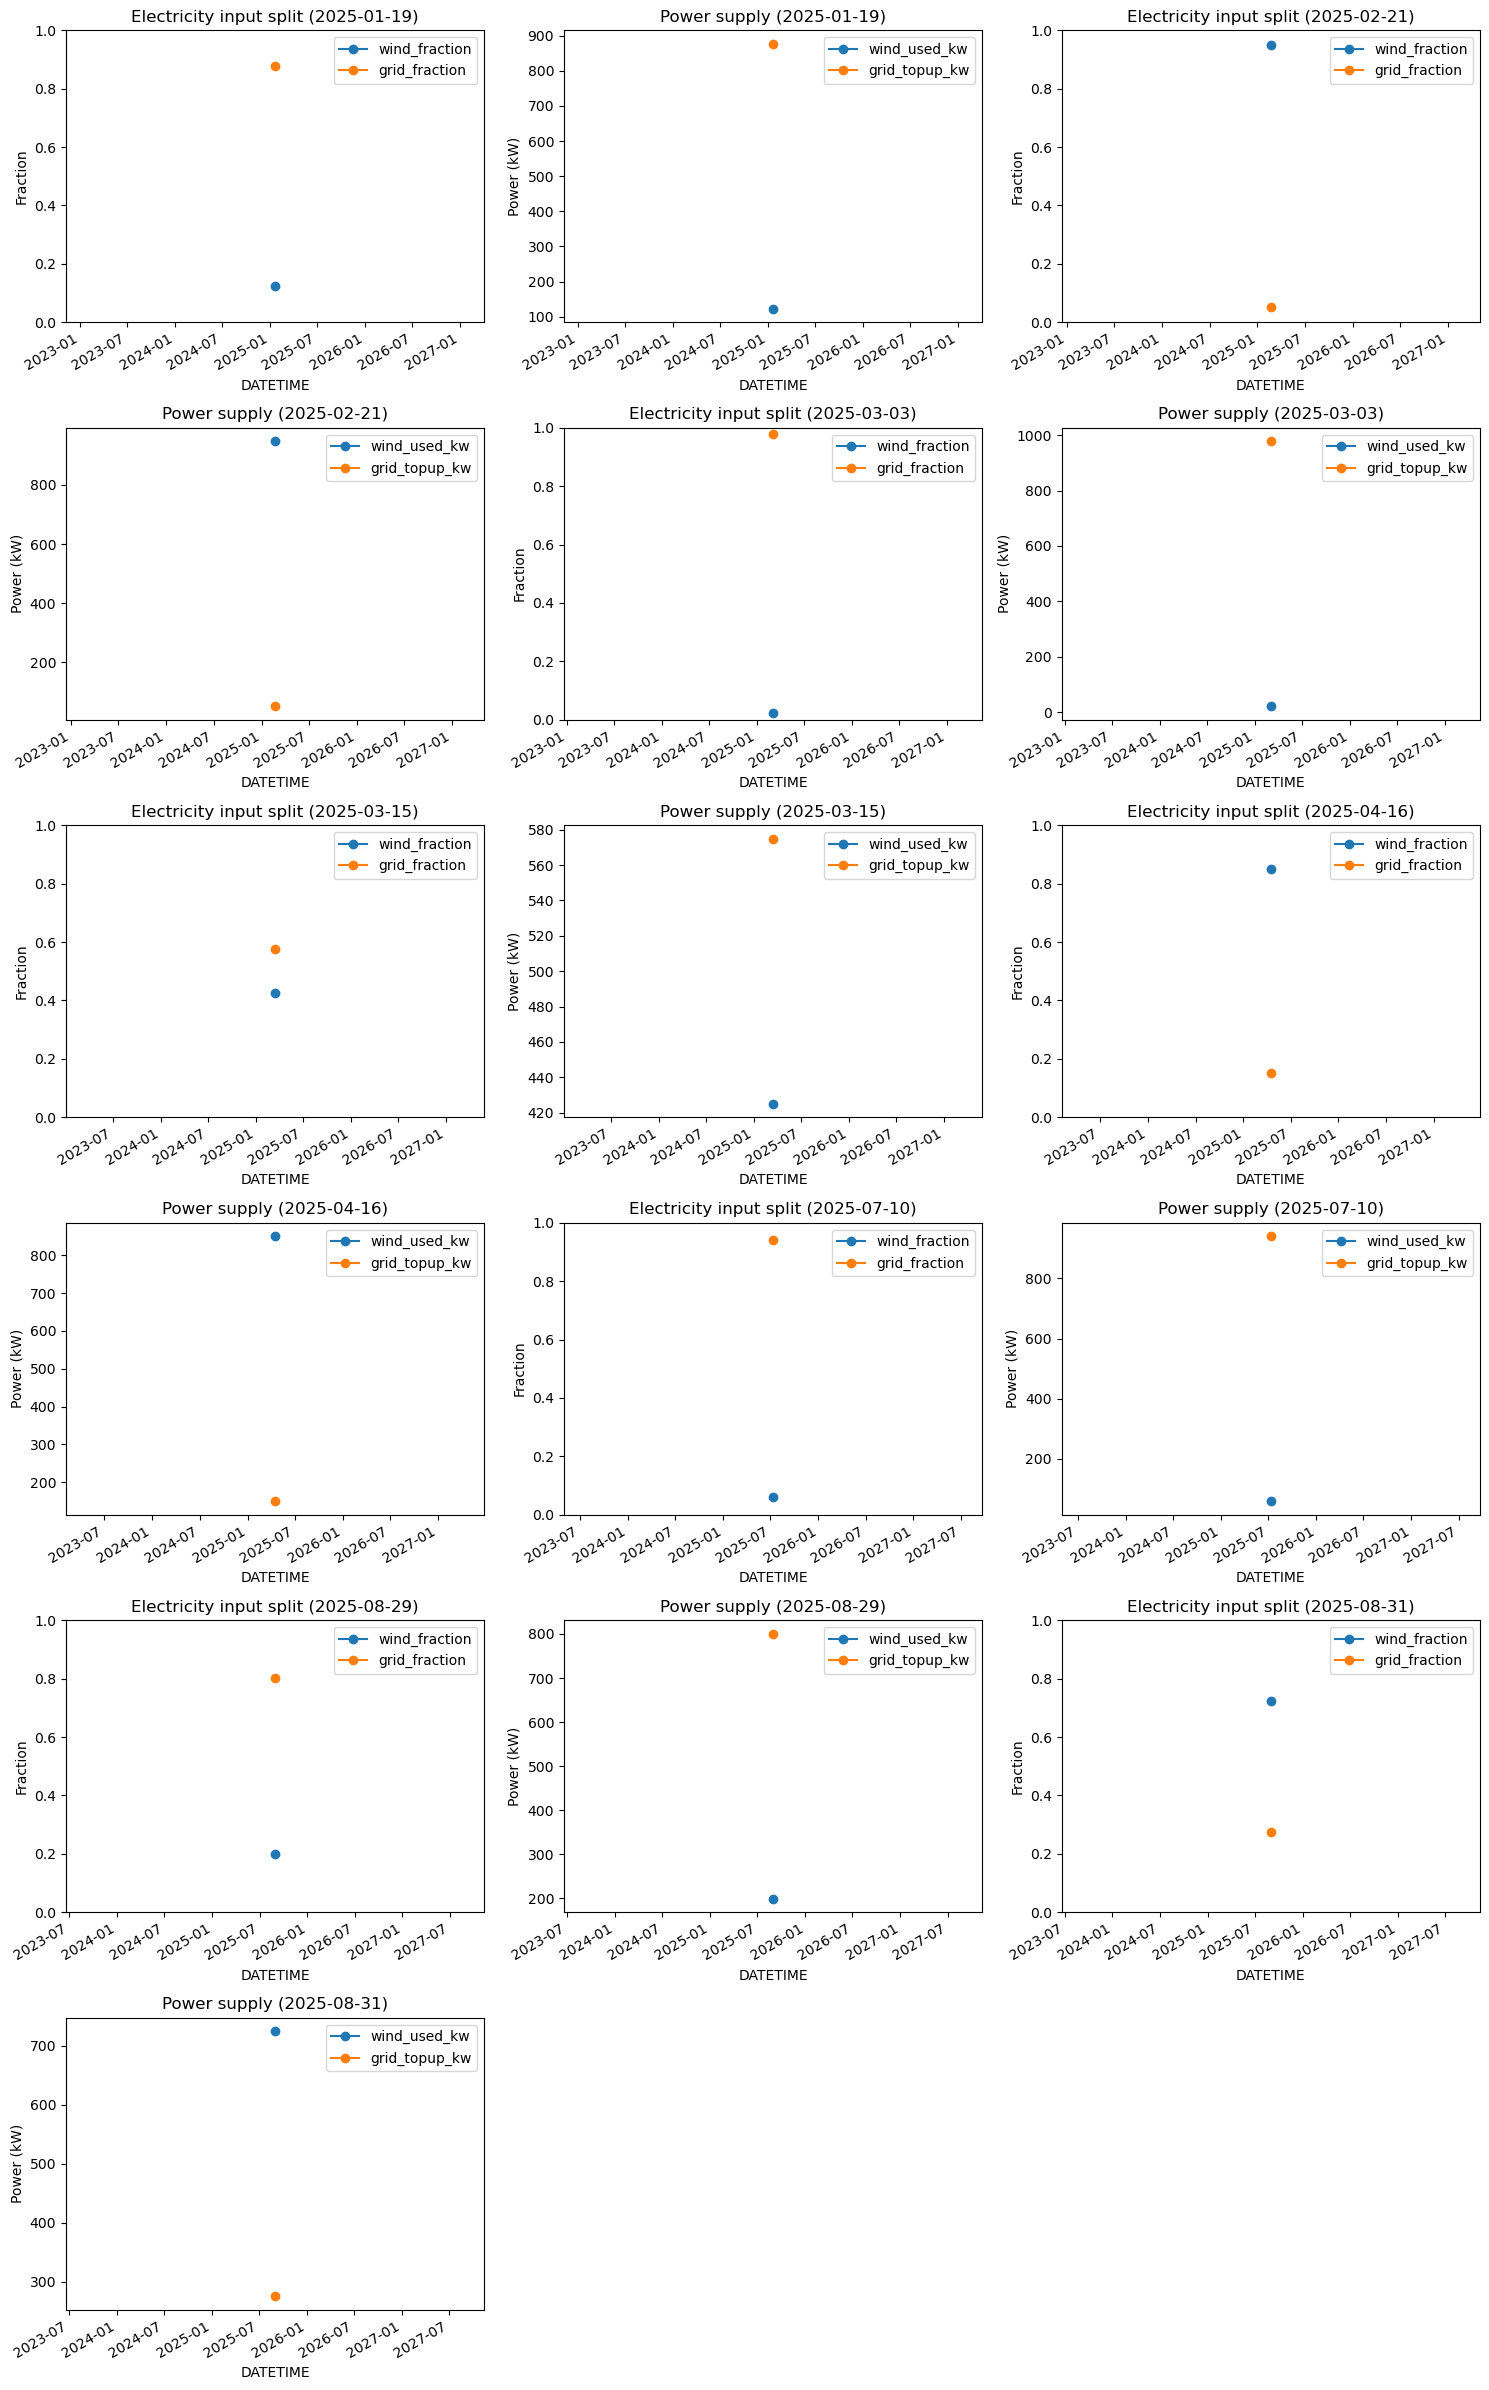

[switching] 12 days; showing first 8 for preview.


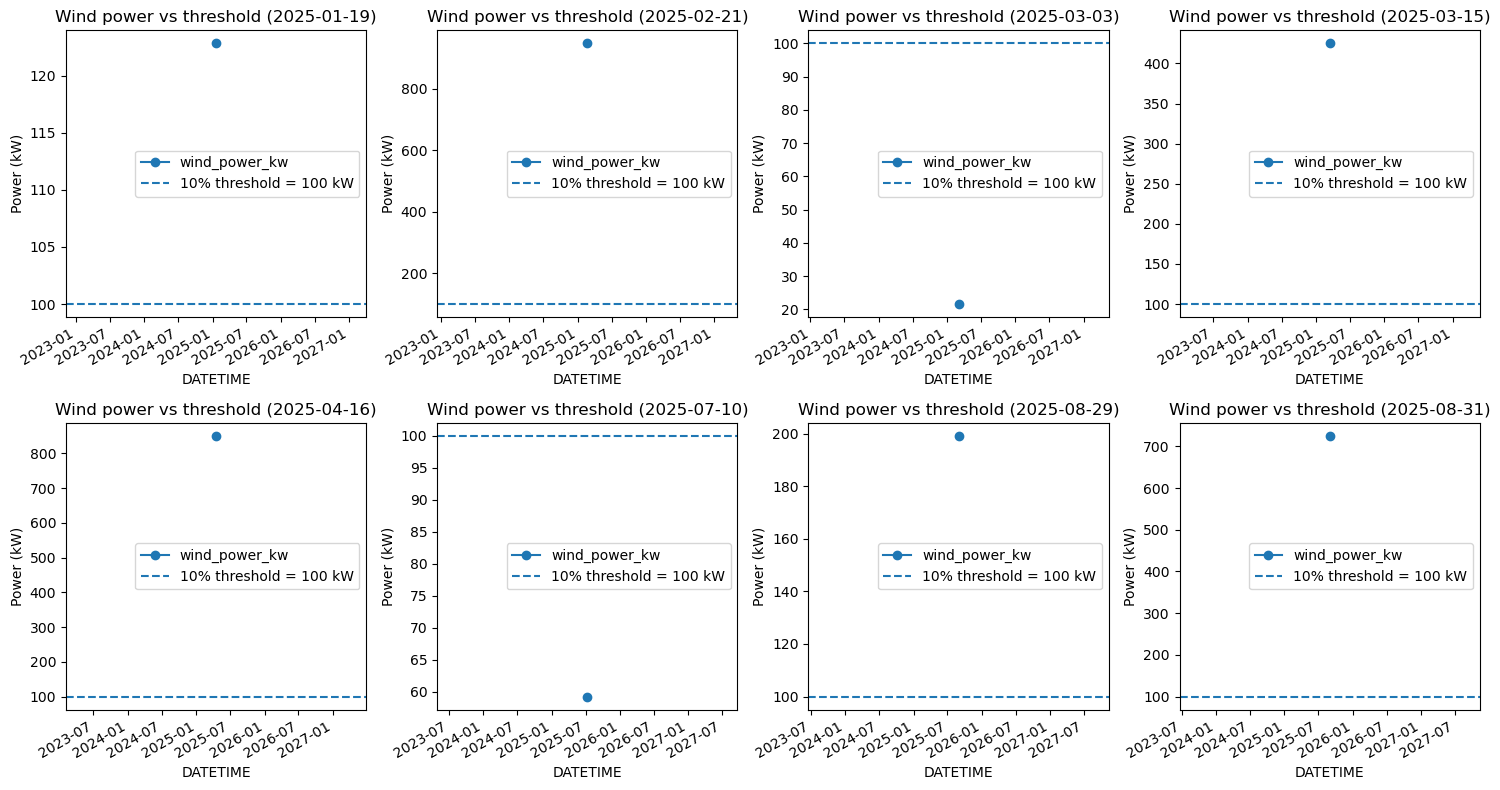

    0 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    1 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: NP
    2 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: RoW
    3 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CA-QC
    4 | name: electricity production, wind, 1-3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: CO
    5 | name: electricity production, wind, 1-3MW turbine, offshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    6 | name: electricity production, wind, >3MW turbine, onshore | ref: electricity, high voltage | unit: kilowatt hour | loc: GB
    7 | name: electricity production, wind, <1MW turbine, onshore | ref:

In [2]:
# Set to True to re-execute each child notebook (the dashboard settings will
# be used automatically because every notebook imports dashboard_config).
RUN_FOREGROUND_NOTEBOOK = True
RUN_GRID_NOTEBOOK       = True
RUN_WIND_NOTEBOOK       = True

# GRID_NOTEBOOK is derived from GRID_DATA_SOURCE in dashboard_config.py:
#   GRID_DATA_SOURCE = "csv"        -> 3.custom_grid.ipynb
#   GRID_DATA_SOURCE = "carbon_api" -> 3.1.custom_grid_carbon_intensity_api.ipynb
from IPython import get_ipython
_ip = get_ipython()

if RUN_FOREGROUND_NOTEBOOK:
    _ip.run_line_magic("run", '"2.tech_lca_foreground.ipynb"')
if RUN_GRID_NOTEBOOK:
    print("Running selected grid notebook:", getattr(cfg, "GRID_NOTEBOOK", "3.custom_grid.ipynb"))
    _ip.run_line_magic("run", f'"{getattr(cfg, "GRID_NOTEBOOK", "3.custom_grid.ipynb")}"')
if RUN_WIND_NOTEBOOK:
    _ip.run_line_magic("run", '"4.wind_power.ipynb"')


## Load the latest result CSVs

In [3]:
from pathlib import Path
import pandas as pd

def latest_csv(folder, patterns=None):
    folder = Path(folder)
    if not folder.exists():
        return None
    patterns = patterns or ["*.csv"]
    if isinstance(patterns, str):
        patterns = [patterns]
    files = []
    for pattern in patterns:
        files.extend(folder.glob(pattern))
    # de-duplicate while preserving Path objects
    files = list({p.resolve(): p for p in files}.values())
    files = sorted(files, key=lambda p: p.stat().st_mtime, reverse=True)
    return files[0] if files else None

grid_patterns = getattr(cfg, "GRID_OUTPUT_GLOBS", [getattr(cfg, "GRID_OUTPUT_GLOB", "*.csv")])
grid_csv = latest_csv(GRID_OUTPUT_DIR, grid_patterns)
print("Custom-grid source: ", getattr(cfg, "GRID_DATA_SOURCE", "csv"))
print("Custom-grid pattern:", grid_patterns)
print("Custom-grid CSV:    ", grid_csv)
if grid_csv is not None:
    grid_df_results = pd.read_csv(grid_csv, parse_dates=["datetime"]).set_index("datetime")
    display(grid_df_results.head())
else:
    grid_df_results = None
    print(f"  (no matching output found — run {getattr(cfg, 'GRID_NOTEBOOK', 'custom_grid.ipynb')})")

if WIND_LCA_MODE == "both":
    # Load both blended and switching CSVs
    blended_csv = latest_csv(WIND_OUTPUT_DIR_BLENDED)
    switching_csv = latest_csv(WIND_OUTPUT_DIR_SWITCHING)
    print("Wind/grid CSV (blended):  ", blended_csv)
    print("Wind/grid CSV (switching):", switching_csv)
    
    dfs = []
    if blended_csv is not None:
        dfs.append(pd.read_csv(blended_csv, parse_dates=["datetime"]))
    if switching_csv is not None:
        dfs.append(pd.read_csv(switching_csv, parse_dates=["datetime"]))
    
    if dfs:
        wind_df_results = pd.concat(dfs, ignore_index=True)
        print(f"  Combined: {len(wind_df_results)} rows")
        display(wind_df_results.head())
    else:
        wind_df_results = None
        print("  (no output found — run wind_power.ipynb)")
else:
    wind_folder = (WIND_OUTPUT_DIR_BLENDED if WIND_LCA_MODE == "blended"
                   else WIND_OUTPUT_DIR_SWITCHING)
    wind_csv = latest_csv(wind_folder)
    print("Wind/grid CSV:      ", wind_csv)
    if wind_csv is not None:
        wind_df_results = pd.read_csv(wind_csv, parse_dates=["datetime"])
        display(wind_df_results.head())
    else:
        wind_df_results = None
        print("  (no output found — run wind_power.ipynb)")

# Attach representative-day labels (REP_SEASON / REP_KIND) to the wind data.
# The wind CSVs don't carry these columns, but the grid CSV does, and both share
# the same half-hour timestamps. Merging on datetime lets every plot/table align
# on the canonical (season, kind) identity instead of fragile raw-date matching.
if (wind_df_results is not None and not wind_df_results.empty
        and grid_df_results is not None and not grid_df_results.empty
        and "REP_SEASON" in grid_df_results.columns
        and "REP_SEASON" not in wind_df_results.columns):
    wind_df_results["datetime"] = pd.to_datetime(wind_df_results["datetime"])
    rep_map = (grid_df_results.reset_index()[["datetime", "REP_SEASON", "REP_KIND"]]
               .drop_duplicates("datetime"))
    wind_df_results = wind_df_results.merge(rep_map, on="datetime", how="left")
    matched = wind_df_results["REP_SEASON"].notna().sum()
    print(f"  Attached REP_SEASON/REP_KIND to wind data: "
          f"{matched}/{len(wind_df_results)} rows matched.")

Custom-grid source:  carbon_api
Custom-grid pattern: ['custom_grid_lca_carbon_api_*.csv']
Custom-grid CSV:     custom_grid_lca_outputs/custom_grid_lca_carbon_api_regional_auto_r13_cheap_2025_api_rep_wind_days.csv


,carbon_intensity,custom_electricity_score,custom_electricity_input_kwh_per_kwh,api_scope,api_region_id,api_region_name,wind_lat,wind_lon,api_total_perc,carbon_intensity_forecast,...,NUCLEAR_perc,WIND_perc,WIND_EMB_perc,HYDRO_perc,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,PEM operation
datetime,,,,,,,,,,,,,,,,,,,,,
2025-12-05 12:00:00,176.812500,0.285952,1.031729,regional_auto,13,London,51.732,-0.3711,100.008333,176.812500,...,9.500000,28.610417,0.0,0.127083,15.943750,1.866667,0.0,1.797917,0.0,15.894904
2025-02-21 12:00:00,90.604167,0.141721,1.031600,regional_auto,13,London,51.732,-0.3711,99.995833,90.604167,...,15.095833,51.935417,0.0,0.100000,12.097917,1.000000,0.0,1.835417,0.0,8.106379
2025-01-19 12:00:00,286.854167,0.432444,1.031213,regional_auto,13,London,51.732,-0.3711,99.958333,286.854167,...,6.602083,5.497917,0.0,0.127083,14.910417,3.793750,0.0,0.300000,0.0,23.805439
2025-03-15 12:00:00,142.375000,0.251581,1.031793,regional_auto,13,London,51.732,-0.3711,100.014583,142.375000,...,3.447917,19.331250,0.0,0.172917,49.589583,0.000000,0.0,4.025000,0.0,14.038855
2025-04-16 12:00:00,78.562500,0.146449,1.031557,regional_auto,13,London,51.732,-0.3711,99.991667,78.562500,...,12.820833,45.647917,0.0,0.122917,14.133333,1.250000,0.0,8.870833,0.0,8.361697


Wind/grid CSV (blended):   blended_wind_grid_lca_outputs/wind_grid_lca_blended_cheap_2025_api_rep_wind_days.csv
Wind/grid CSV (switching): hybrid_wind_grid_lca_outputs/wind_grid_lca_switching_cheap_2025_api_rep_wind_days.csv
  Combined: 24 rows


,datetime,lca_mode,electrolyser_tech,scenario,wind_power_kw,grid_carbon_intensity_gco2_per_kwh,electricity_source,wind_fraction,grid_fraction,wind_used_kw,grid_topup_kw,surplus_wind_kw,wind_above_minimum,gwp100_kgco2e_per_kg_h2,electricity_exchanges_swapped,direct_electricity_kwh_per_kg_h2,wind_electricity_kwh_per_kg_h2,grid_electricity_kwh_per_kg_h2,temporary_grid_activity_code,minimum_required_wind_kw
0,2025-01-19 12:00:00,blended,AE operation,AE operation (blended),122.826,286.854167,blended,0.122826,0.877174,122.826,877.174,0.0,NaN,20.171387,1,51.8,6.362387,45.437613,NaN,NaN
1,2025-02-21 12:00:00,blended,AE operation,AE operation (blended),948.082,90.604167,blended,0.948082,0.051918,948.082,51.918,0.0,NaN,1.521696,1,51.8,49.110648,2.689352,NaN,NaN
2,2025-03-03 12:00:00,blended,AE operation,AE operation (blended),21.632,215.833333,blended,0.021632,0.978368,21.632,978.368,0.0,NaN,17.447435,1,51.8,1.120538,50.679462,NaN,NaN
3,2025-03-15 12:00:00,blended,AE operation,AE operation (blended),425.043,142.375000,blended,0.425043,0.574957,425.043,574.957,0.0,NaN,8.241416,1,51.8,22.017227,29.782773,NaN,NaN
4,2025-04-16 12:00:00,blended,AE operation,AE operation (blended),850.619,78.562500,blended,0.850619,0.149381,850.619,149.381,0.0,NaN,2.200738,1,51.8,44.062064,7.737936,NaN,NaN


  Attached REP_SEASON/REP_KIND to wind data: 24/24 rows matched.


## Plot: custom-grid LCA GWP100 over selected timeslices

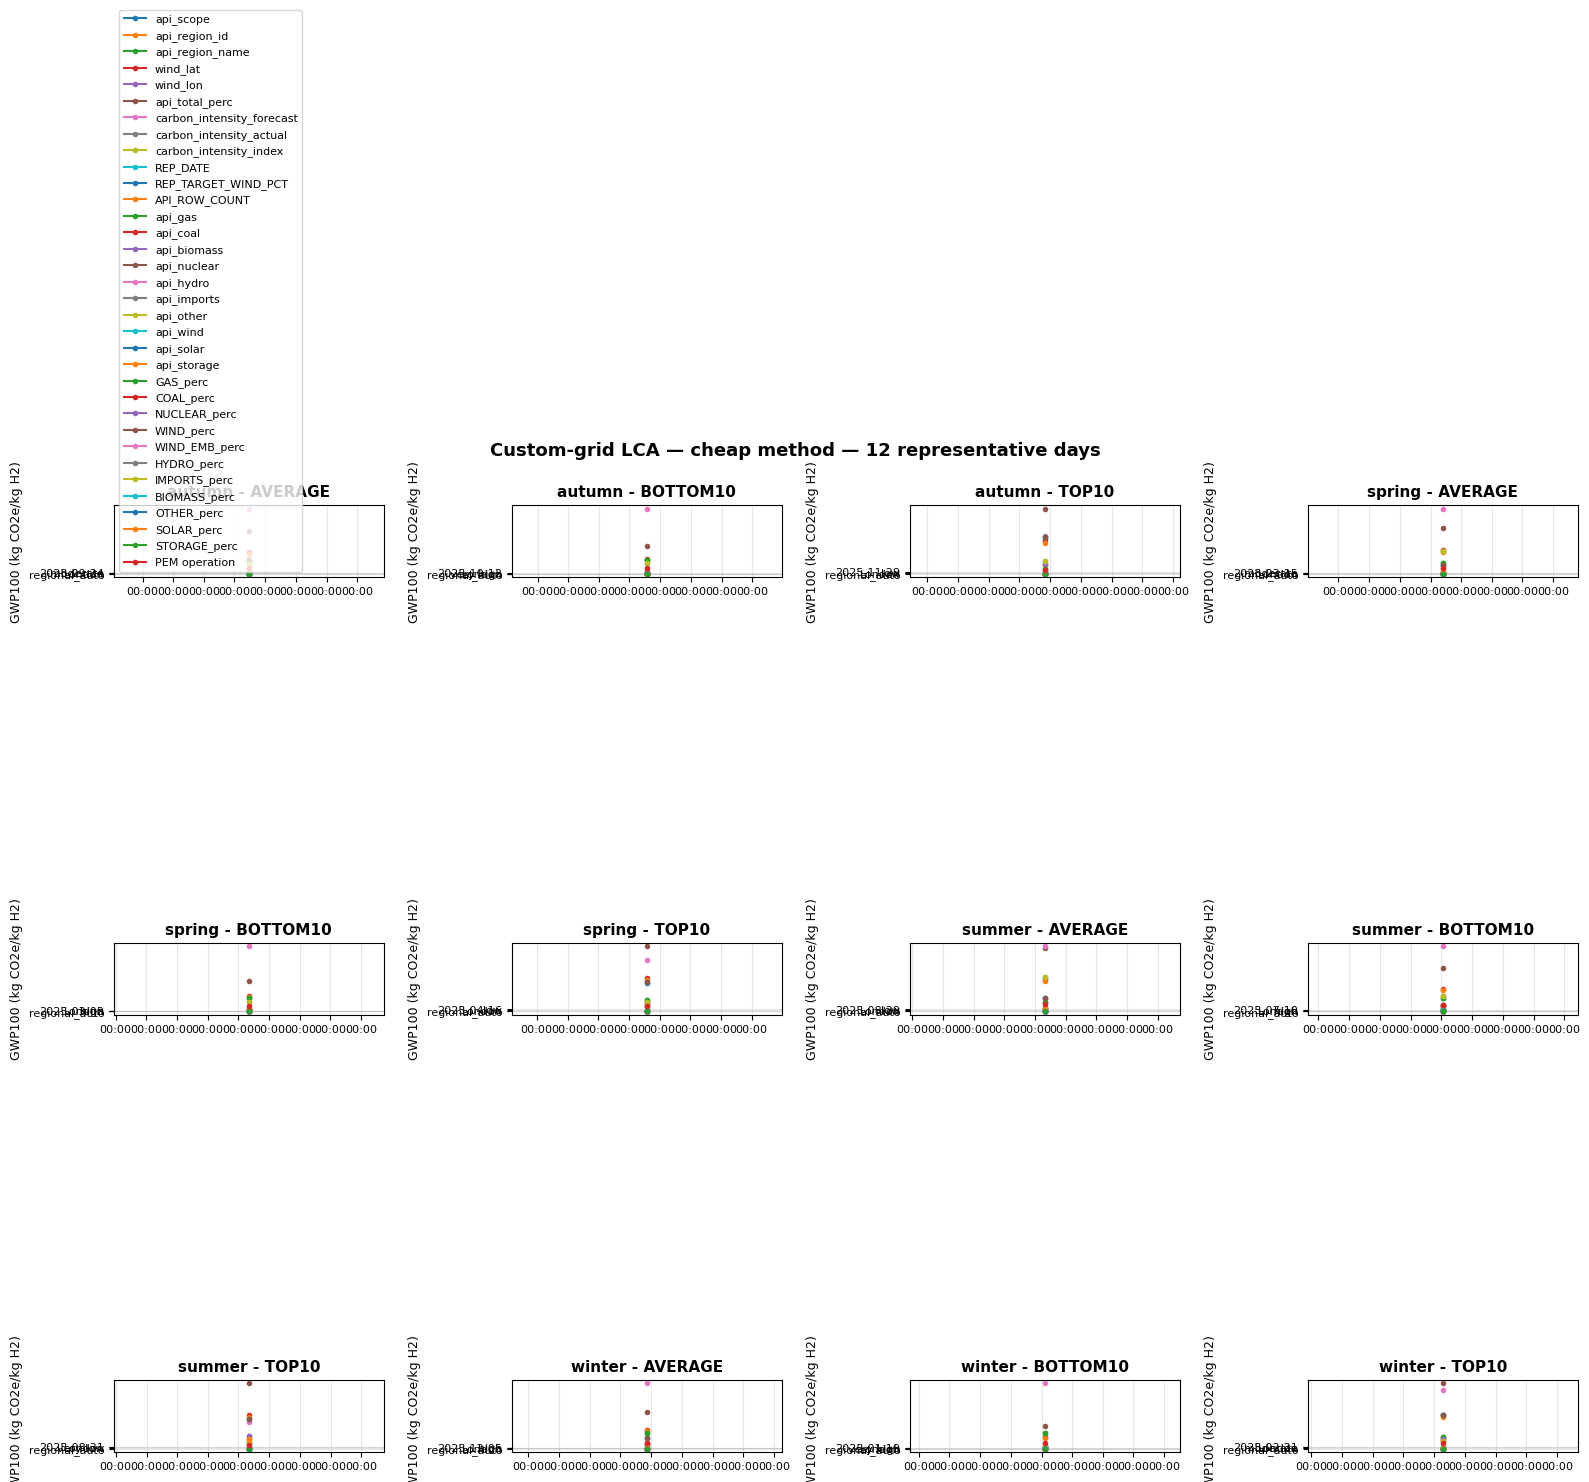

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if grid_df_results is None or grid_df_results.empty:
    print("Skipping custom-grid plot — no results loaded.")
else:
    metadata_cols = {
        "carbon_intensity", "custom_electricity_score",
        "custom_electricity_input_kwh_per_kwh", "REP_SEASON", "REP_KIND",
    }
    tech_cols = [c for c in grid_df_results.columns if c not in metadata_cols]
    
    # Check if we have representative day info
    if "REP_SEASON" in grid_df_results.columns and "REP_KIND" in grid_df_results.columns:
        # Create subplots for each representative day
        runs = sorted(grid_df_results.groupby(["REP_SEASON", "REP_KIND"]).groups.keys())
        n_runs = len(runs)
        n_cols = 4
        n_rows = (n_runs + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5*n_rows))
        axes = axes.flatten()
        
        for ax_idx, (season, kind) in enumerate(runs):
            rep_data = grid_df_results[
                (grid_df_results["REP_SEASON"] == season) & 
                (grid_df_results["REP_KIND"] == kind)
            ]
            
            ax = axes[ax_idx]
            for tech in tech_cols:
                ax.plot(rep_data.index, rep_data[tech], marker="o", label=tech,
                       linewidth=1.5, markersize=3)
            
            ax.set_title(f"{season} - {kind.upper()}", fontsize=11, fontweight="bold")
            ax.set_ylabel("GWP100 (kg CO2e/kg H2)", fontsize=9)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.tick_params(axis="x", labelsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.grid(True, alpha=0.3)
            if ax_idx == 0:
                ax.legend(fontsize=8, loc="best")
        
        # Hide unused subplots
        for ax_idx in range(len(runs), len(axes)):
            axes[ax_idx].set_visible(False)
        
        fig.suptitle(f"Custom-grid LCA — {METHOD_MODE} method — 12 representative days",
                    fontsize=13, fontweight="bold", y=0.995)
        fig.tight_layout()
        plt.show()
    
    else:
        # Fallback: single aggregated plot if no rep day info
        fig, ax1 = plt.subplots(figsize=(13, 6))
        for tech in tech_cols:
            ax1.plot(grid_df_results.index, grid_df_results[tech],
                     label=tech, color=H.TECH_COLOURS.get(tech),
                     linewidth=1.8, marker="o", markersize=3)

        ax1.set_xlabel("Time (UTC)", fontsize=11)
        ax1.set_ylabel("GWP100  (kg CO2eq / kg H2)", fontsize=11)
        ax1.set_title(f"Hydrogen GWP100 over selected timeslices — {METHOD_MODE} method",
                      fontsize=13)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
        ax1.legend(loc="upper right", fontsize=10, framealpha=0.85)
        ax1.grid(True, linestyle="--", alpha=0.4)

        if "custom_electricity_score" in grid_df_results.columns \
           and grid_df_results["custom_electricity_score"].notna().any():
            ax2 = ax1.twinx()
            ax2.plot(grid_df_results.index, grid_df_results["custom_electricity_score"],
                     color="grey", linewidth=1.2, linestyle=":",
                     label="Custom electricity score (kg CO2eq/kWh)")
            ax2.set_ylabel("Custom electricity score  (kg CO2eq/kWh)",
                           fontsize=10, color="grey")
            ax2.tick_params(axis="y", labelcolor="grey")
            ax2.legend(loc="upper left", fontsize=9, framealpha=0.75)
        elif "carbon_intensity" in grid_df_results.columns \
             and grid_df_results["carbon_intensity"].notna().any():
            ax2 = ax1.twinx()
            ax2.plot(grid_df_results.index, grid_df_results["carbon_intensity"],
                     color="grey", linewidth=1.2, linestyle=":",
                     label="Grid CI (g CO2eq/kWh)")
            ax2.set_ylabel("Grid carbon intensity (g CO2eq/kWh)", fontsize=10, color="grey")
            ax2.tick_params(axis="y", labelcolor="grey")
            ax2.legend(loc="upper left", fontsize=9, framealpha=0.75)

        fig.tight_layout()
        plt.show()


## Plot: wind/grid LCA GWP100 over the 48 slices

In [5]:

# === DIAGNOSTIC: What's being loaded and plotted ===
print("=" * 80)
print("DATA LOADING DIAGNOSTICS")
print("=" * 80)

print("\n1. CONFIG SETTINGS:")
print(f"   WIND_LCA_MODE = {WIND_LCA_MODE}")
print(f"   WIND_OUTPUT_DIR_BLENDED = {WIND_OUTPUT_DIR_BLENDED}")
print(f"   WIND_OUTPUT_DIR_SWITCHING = {WIND_OUTPUT_DIR_SWITCHING}")

print("\n2. WIND DATA LOADED:")
if wind_df_results is not None and not wind_df_results.empty:
    print(f"   Shape: {wind_df_results.shape}")
    print(f"   Columns: {list(wind_df_results.columns)}")
    print(f"\n   Unique lca_modes: {sorted(wind_df_results['lca_mode'].unique())}")
    for mode in sorted(wind_df_results['lca_mode'].unique()):
        count = len(wind_df_results[wind_df_results['lca_mode'] == mode])
        techs = wind_df_results[wind_df_results['lca_mode'] == mode]['electrolyser_tech'].unique()
        print(f"     - {mode}: {count} rows, techs={list(techs)}")
else:
    print("   (No wind data loaded)")

print("\n3. GRID DATA LOADED:")
if grid_df_results is not None and not grid_df_results.empty:
    print(f"   Shape: {grid_df_results.shape}")
    metadata_cols = {"carbon_intensity", "custom_electricity_score",
                     "custom_electricity_input_kwh_per_kwh", "REP_SEASON", "REP_KIND"}
    tech_cols = [c for c in grid_df_results.columns if c not in metadata_cols]
    print(f"   Tech columns: {tech_cols}")
    print(f"   REP_SEASON values: {sorted(grid_df_results['REP_SEASON'].unique())}")
    print(f"   REP_KIND values: {sorted(grid_df_results['REP_KIND'].unique())}")
else:
    print("   (No grid data loaded)")

print("\n4. PLOT GRID LAYOUT:")
print("   Column 0: Blended wind/grid mode")
print("   Column 1: Switching wind/grid mode")
print("   Column 2: Custom grid LCA")

print("\n" + "=" * 80)
print("If any columns are empty in the plot grid, check the diagnostics above.")
print("=" * 80 + "\n")



DATA LOADING DIAGNOSTICS

1. CONFIG SETTINGS:
   WIND_LCA_MODE = both
   WIND_OUTPUT_DIR_BLENDED = blended_wind_grid_lca_outputs
   WIND_OUTPUT_DIR_SWITCHING = hybrid_wind_grid_lca_outputs

2. WIND DATA LOADED:
   Shape: (24, 22)
   Columns: ['datetime', 'lca_mode', 'electrolyser_tech', 'scenario', 'wind_power_kw', 'grid_carbon_intensity_gco2_per_kwh', 'electricity_source', 'wind_fraction', 'grid_fraction', 'wind_used_kw', 'grid_topup_kw', 'surplus_wind_kw', 'wind_above_minimum', 'gwp100_kgco2e_per_kg_h2', 'electricity_exchanges_swapped', 'direct_electricity_kwh_per_kg_h2', 'wind_electricity_kwh_per_kg_h2', 'grid_electricity_kwh_per_kg_h2', 'temporary_grid_activity_code', 'minimum_required_wind_kw', 'REP_SEASON', 'REP_KIND']

   Unique lca_modes: ['blended', 'switching']
     - blended: 12 rows, techs=['AE operation']
     - switching: 12 rows, techs=['AE operation']

3. GRID DATA LOADED:
   Shape: (12, 39)
   Tech columns: ['api_scope', 'api_region_id', 'api_region_name', 'wind_lat', 

/var/folders/4k/86frdt4j30v2q39zm0kp7v140000gn/T/ipykernel_61673/2692369937.py:107: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


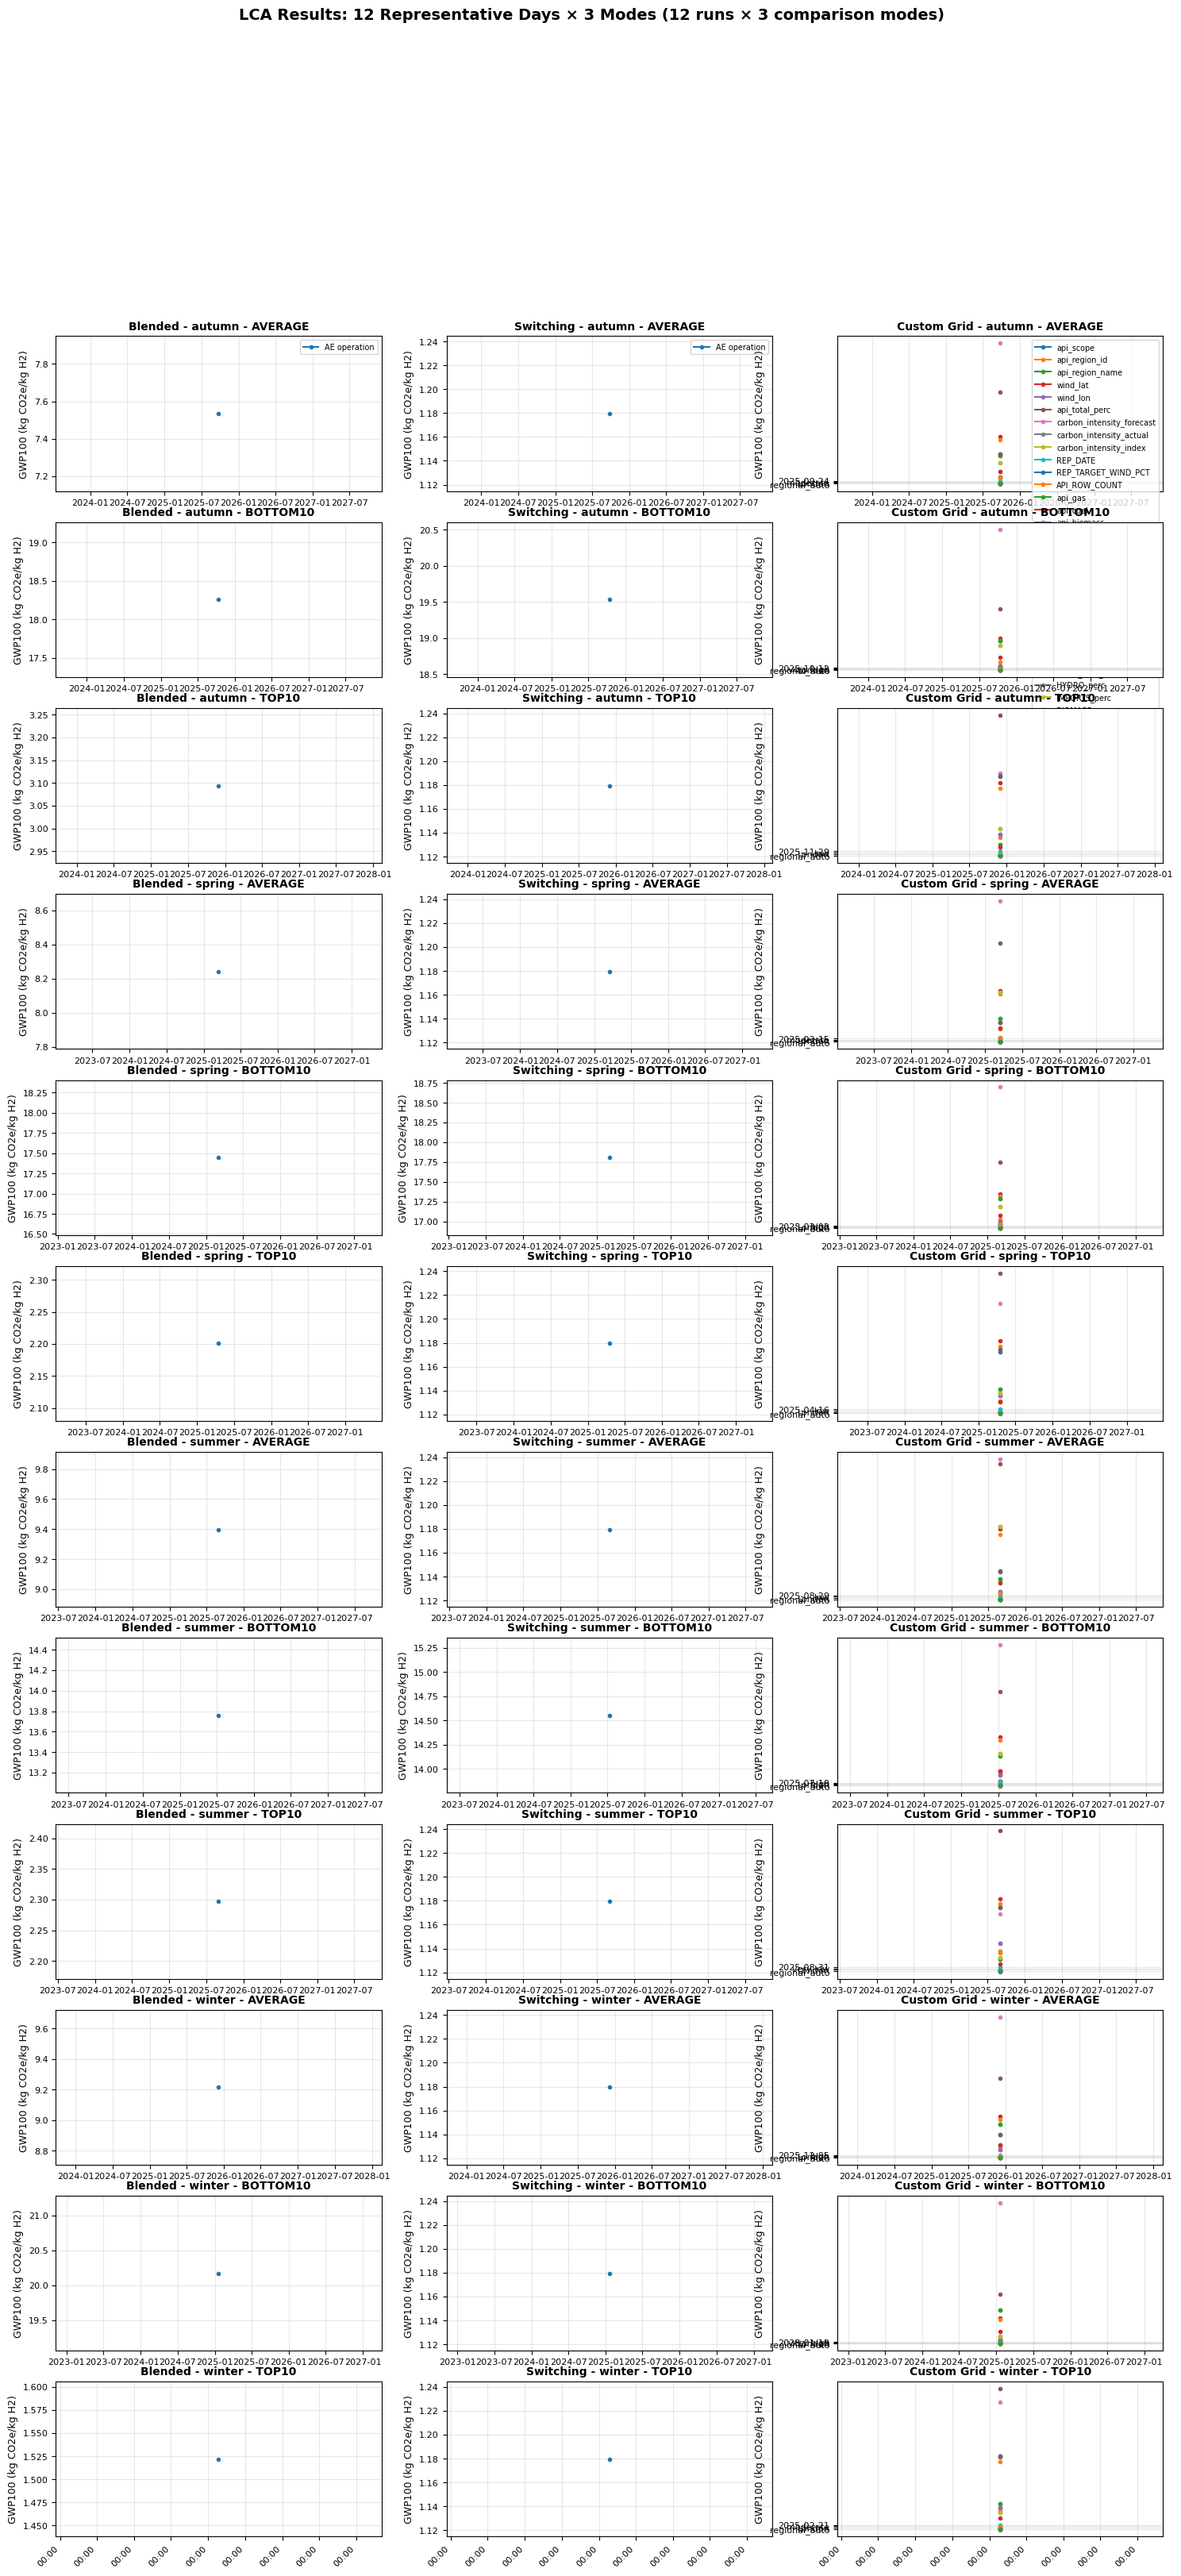

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

if wind_df_results is None or wind_df_results.empty or grid_df_results is None or grid_df_results.empty:
    print("Skipping 12x3 representative day plots — need both wind and grid results.")
else:
    wind_df_results["datetime"] = pd.to_datetime(wind_df_results["datetime"])
    
    # Identify unique representative runs from wind data
    if "REP_SEASON" in wind_df_results.columns and "REP_KIND" in wind_df_results.columns:
        runs = sorted(set(map(tuple,
            wind_df_results[["REP_SEASON", "REP_KIND"]].dropna().itertuples(index=False, name=None))))
        run_labels = [f"{season}\n{kind}" for season, kind in runs]
    else:
        # Fallback: group by unique dates if rep columns not present
        wind_df_results["date_only"] = wind_df_results["datetime"].dt.date
        runs = sorted(wind_df_results["date_only"].unique())
        run_labels = [str(d) for d in runs]
    
    n_runs = len(runs)
    modes = ["blended", "switching", "custom_grid"]
    
    # Create 12 rows × 3 columns grid
    fig, axes = plt.subplots(n_runs, 3, figsize=(18, 3*n_runs))
    if n_runs == 1:
        axes = axes.reshape(1, -1)
    
    for row_idx, run in enumerate(runs):
        # Extract data for this representative run
        if "REP_SEASON" in wind_df_results.columns:
            season, kind = run
            wind_run = wind_df_results[
                (wind_df_results["REP_SEASON"] == season) & 
                (wind_df_results["REP_KIND"] == kind)
            ]
            grid_run = grid_df_results[
                (grid_df_results["REP_SEASON"] == season) & 
                (grid_df_results["REP_KIND"] == kind)
            ]
            run_title = f"{season} - {kind.upper()}"
        else:
            date_val = run
            wind_run = wind_df_results[wind_df_results["date_only"] == date_val]
            grid_run = grid_df_results.loc[grid_df_results.index.date == date_val]
            run_title = str(date_val)
        
        # Column 0: Blended mode
        ax_blended = axes[row_idx, 0]
        blended_df = wind_run[wind_run["lca_mode"] == "blended"]
        if not blended_df.empty:
            for tech in ELECTROLYSER_TECHS:
                tech_data = blended_df[blended_df["electrolyser_tech"] == tech]
                if not tech_data.empty:
                    ax_blended.plot(tech_data["datetime"], tech_data["gwp100_kgco2e_per_kg_h2"],
                                   marker="o", label=tech, markersize=3, linewidth=1.5)
        ax_blended.set_title(f"Blended - {run_title}", fontsize=10, fontweight="bold")
        ax_blended.set_ylabel("GWP100 (kg CO2e/kg H2)", fontsize=9)
        ax_blended.grid(True, alpha=0.3)
        ax_blended.tick_params(axis="x", labelsize=8)
        ax_blended.tick_params(axis="y", labelsize=8)
        if row_idx == 0:
            ax_blended.legend(fontsize=7, loc="best")
        
        # Column 1: Switching mode
        ax_switching = axes[row_idx, 1]
        switching_df = wind_run[wind_run["lca_mode"] == "switching"]
        if not switching_df.empty:
            for tech in ELECTROLYSER_TECHS:
                tech_data = switching_df[switching_df["electrolyser_tech"] == tech]
                if not tech_data.empty:
                    ax_switching.plot(tech_data["datetime"], tech_data["gwp100_kgco2e_per_kg_h2"],
                                     marker="o", label=tech, markersize=3, linewidth=1.5)
        ax_switching.set_title(f"Switching - {run_title}", fontsize=10, fontweight="bold")
        ax_switching.set_ylabel("GWP100 (kg CO2e/kg H2)", fontsize=9)
        ax_switching.grid(True, alpha=0.3)
        ax_switching.tick_params(axis="x", labelsize=8)
        ax_switching.tick_params(axis="y", labelsize=8)
        if row_idx == 0:
            ax_switching.legend(fontsize=7, loc="best")
        
        # Column 2: Custom grid mode
        ax_grid = axes[row_idx, 2]
        if not grid_run.empty:
            grid_run = grid_run.sort_index()
            metadata_cols = {"carbon_intensity", "custom_electricity_score",
                           "custom_electricity_input_kwh_per_kwh", "REP_SEASON", "REP_KIND"}
            tech_cols = [c for c in grid_run.columns if c not in metadata_cols]
            for tech in tech_cols:
                ax_grid.plot(grid_run.index, grid_run[tech], marker="o",
                            label=tech, markersize=3, linewidth=1.5)
        ax_grid.set_title(f"Custom Grid - {run_title}", fontsize=10, fontweight="bold")
        ax_grid.set_ylabel("GWP100 (kg CO2e/kg H2)", fontsize=9)
        ax_grid.grid(True, alpha=0.3)
        ax_grid.tick_params(axis="x", labelsize=8)
        ax_grid.tick_params(axis="y", labelsize=8)
        if row_idx == 0:
            ax_grid.legend(fontsize=7, loc="best")
    
    # Rotate x-axis labels for all bottom row cells
    for col in range(3):
        axes[n_runs-1, col].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        plt.setp(axes[n_runs-1, col].xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)
    
    fig.suptitle(f"LCA Results: 12 Representative Days × 3 Modes ({n_runs} runs × 3 comparison modes)",
                 fontsize=14, fontweight="bold", y=0.995)
    fig.tight_layout()
    plt.show()


## Mode-specific wind/grid plot

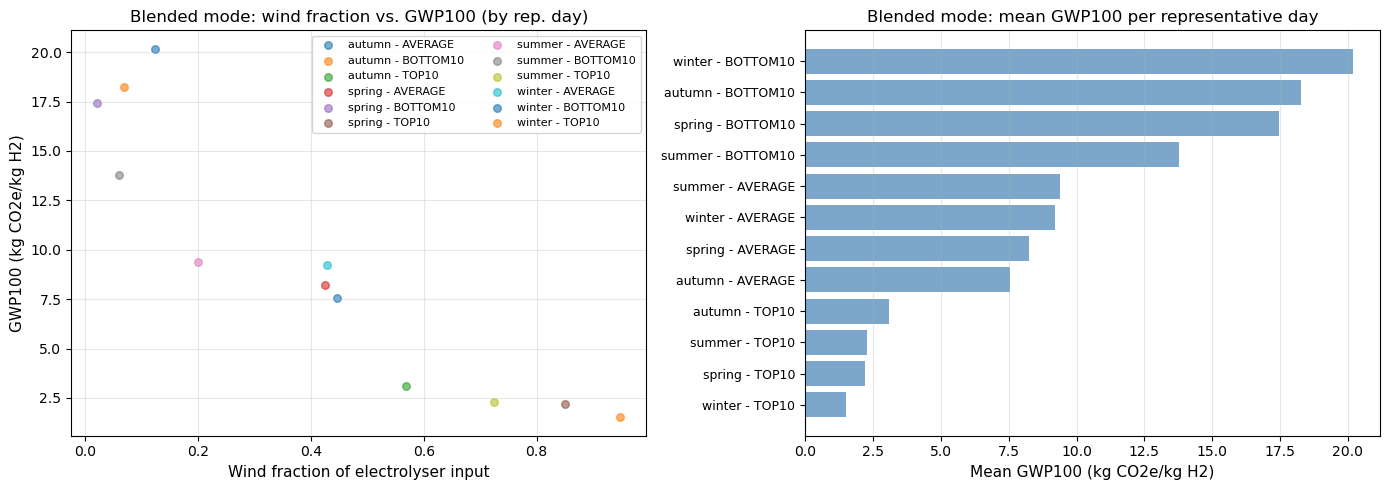

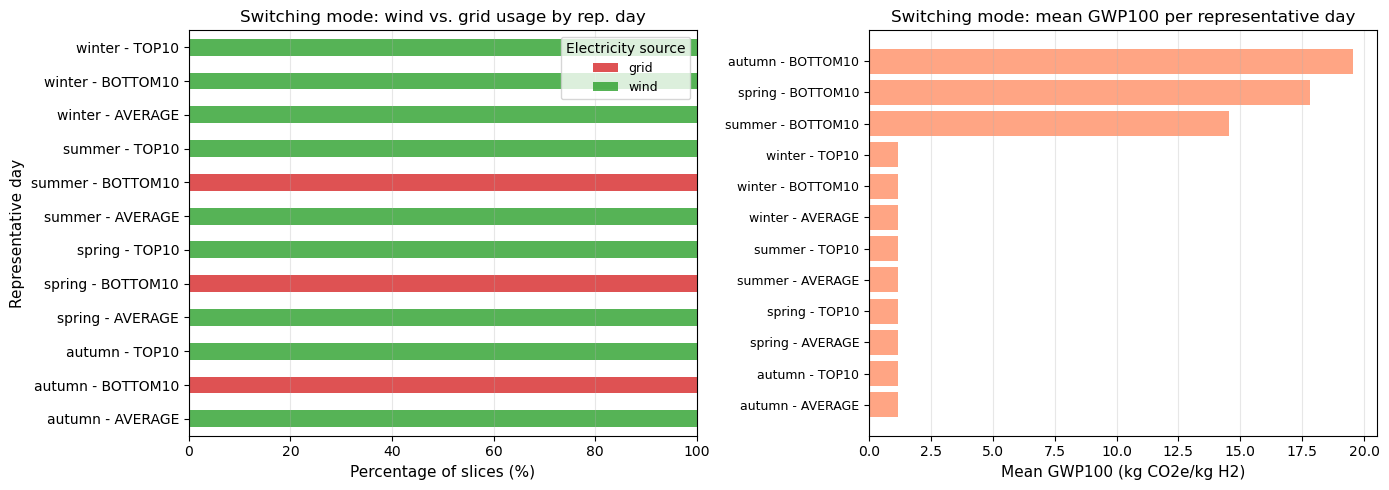

In [7]:
import matplotlib.pyplot as plt

if wind_df_results is None or wind_df_results.empty:
    print("Skipping mode-specific analysis.")
else:
    wind_df_results["datetime"] = pd.to_datetime(wind_df_results["datetime"])
    
    # Add rep day identifier if available
    if "REP_SEASON" in wind_df_results.columns and "REP_KIND" in wind_df_results.columns:
        wind_df_results["rep_day"] = (wind_df_results["REP_SEASON"] + " - " + 
                                      wind_df_results["REP_KIND"].str.upper())
    else:
        wind_df_results["rep_day"] = wind_df_results["datetime"].dt.date
    
    # Blended mode analysis: wind fraction distribution
    if WIND_LCA_MODE in ("blended", "both"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        blended_df = wind_df_results[wind_df_results["lca_mode"] == "blended"]
        if not blended_df.empty:
            # Left: Wind fraction vs GWP100 per representative day
            for rep_day in sorted(blended_df["rep_day"].unique()):
                day_df = blended_df[blended_df["rep_day"] == rep_day]
                ax1.scatter(day_df["wind_fraction"], day_df["gwp100_kgco2e_per_kg_h2"],
                           label=rep_day, alpha=0.6, s=30)
            ax1.set_xlabel("Wind fraction of electrolyser input", fontsize=11)
            ax1.set_ylabel("GWP100 (kg CO2e/kg H2)", fontsize=11)
            ax1.set_title("Blended mode: wind fraction vs. GWP100 (by rep. day)", fontsize=12)
            ax1.legend(fontsize=8, loc="best", ncol=2)
            ax1.grid(True, alpha=0.3)
            
            # Right: Mean GWP100 per representative day
            blended_summary = blended_df.groupby("rep_day")["gwp100_kgco2e_per_kg_h2"].mean().sort_values()
            ax2.barh(range(len(blended_summary)), blended_summary.values, color="steelblue", alpha=0.7)
            ax2.set_yticks(range(len(blended_summary)))
            ax2.set_yticklabels(blended_summary.index, fontsize=9)
            ax2.set_xlabel("Mean GWP100 (kg CO2e/kg H2)", fontsize=11)
            ax2.set_title("Blended mode: mean GWP100 per representative day", fontsize=12)
            ax2.grid(True, alpha=0.3, axis="x")
            
            fig.tight_layout()
            plt.show()
    
    # Switching mode analysis: electricity source distribution
    if WIND_LCA_MODE in ("switching", "both"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        switching_df = wind_df_results[wind_df_results["lca_mode"] == "switching"]
        if not switching_df.empty:
            # Left: Wind vs grid usage by representative day
            src_by_day = switching_df.groupby(["rep_day", "electricity_source"]).size().unstack(fill_value=0)
            src_by_day_pct = src_by_day.div(src_by_day.sum(axis=1), axis=0) * 100
            src_by_day_pct.plot(kind="barh", stacked=True, ax=ax1, 
                               color=["#d62728", "#2ca02c"], alpha=0.8)
            ax1.set_xlabel("Percentage of slices (%)", fontsize=11)
            ax1.set_ylabel("Representative day", fontsize=11)
            ax1.set_title("Switching mode: wind vs. grid usage by rep. day", fontsize=12)
            ax1.legend(title="Electricity source", fontsize=9)
            ax1.grid(True, alpha=0.3, axis="x")
            
            # Right: Mean GWP100 per representative day
            switching_summary = switching_df.groupby("rep_day")["gwp100_kgco2e_per_kg_h2"].mean().sort_values()
            ax2.barh(range(len(switching_summary)), switching_summary.values, color="coral", alpha=0.7)
            ax2.set_yticks(range(len(switching_summary)))
            ax2.set_yticklabels(switching_summary.index, fontsize=9)
            ax2.set_xlabel("Mean GWP100 (kg CO2e/kg H2)", fontsize=11)
            ax2.set_title("Switching mode: mean GWP100 per representative day", fontsize=12)
            ax2.grid(True, alpha=0.3, axis="x")
            
            fig.tight_layout()
            plt.show()


## Combined summary table

In [8]:
import pandas as pd

rows = []

# Grid results summary
if grid_df_results is not None and not grid_df_results.empty:
    metadata_cols = {"carbon_intensity", "custom_electricity_score",
                     "custom_electricity_input_kwh_per_kwh", "REP_SEASON", "REP_KIND"}
    
    if "REP_SEASON" in grid_df_results.columns and "REP_KIND" in grid_df_results.columns:
        # Break down by representative day
        for (season, kind), group in grid_df_results.groupby(["REP_SEASON", "REP_KIND"]):
            for tech in [c for c in group.columns if c not in metadata_cols]:
                s = group[tech]
                rows.append({
                    "source": "custom_grid", "rep_day": f"{season} - {kind.upper()}",
                    "technology": tech,
                    "n_slices": int(s.notna().sum()),
                    "mean_gwp100": s.mean(), "min_gwp100": s.min(), "max_gwp100": s.max(),
                })
    else:
        # No rep day info, just aggregate
        for tech in [c for c in grid_df_results.columns if c not in metadata_cols]:
            s = grid_df_results[tech]
            rows.append({
                "source": "custom_grid", "rep_day": "all",
                "technology": tech,
                "n_slices": int(s.notna().sum()),
                "mean_gwp100": s.mean(), "min_gwp100": s.min(), "max_gwp100": s.max(),
            })

# Wind/grid results summary
if wind_df_results is not None and not wind_df_results.empty:
    wind_df_results["datetime"] = pd.to_datetime(wind_df_results["datetime"])
    
    if "REP_SEASON" in wind_df_results.columns and "REP_KIND" in wind_df_results.columns:
        # Break down by representative day and LCA mode
        for (season, kind, mode, tech), group in wind_df_results.groupby(
            ["REP_SEASON", "REP_KIND", "lca_mode", "electrolyser_tech"]
        ):
            s = group["gwp100_kgco2e_per_kg_h2"]
            rows.append({
                "source": "wind_grid", "rep_day": f"{season} - {kind.upper()}",
                "lca_mode": mode, "technology": tech,
                "n_slices": int(s.notna().sum()),
                "mean_gwp100": s.mean(), "min_gwp100": s.min(), "max_gwp100": s.max(),
            })
    else:
        # No rep day info
        for (mode, tech), group in wind_df_results.groupby(["lca_mode", "electrolyser_tech"]):
            s = group["gwp100_kgco2e_per_kg_h2"]
            rows.append({
                "source": "wind_grid", "rep_day": "all",
                "lca_mode": mode, "technology": tech,
                "n_slices": int(s.notna().sum()),
                "mean_gwp100": s.mean(), "min_gwp100": s.min(), "max_gwp100": s.max(),
            })

if rows:
    summary = pd.DataFrame(rows)
    # Set appropriate multi-index based on available columns
    if "lca_mode" in summary.columns:
        summary = summary.set_index(["source", "rep_day", "lca_mode", "technology"])
    else:
        summary = summary.set_index(["source", "rep_day", "technology"])
    
    # Sort for better readability
    summary = summary.sort_index()
    display(summary)
else:
    print("No results to summarise. Run the building-block notebooks first.")


TypeError: Cannot perform reduction 'mean' with string dtype